Install Dependencies

In [ ]:
!pip install -q transformers peft datasets accelerate bitsandbytes trl torch

Upload and Load Dataset

In [9]:
import json

with open("ecommerce.json", "r") as f:
    ecommerce_data = json.load(f)

with open("education.json", "r") as f:
    education_data = json.load(f)

print(f"E-commerce samples: {len(ecommerce_data)}")
print(f"Education samples: {len(education_data)}")

print(json.dumps(ecommerce_data[0], indent=2))

E-commerce samples: 1000
Education samples: 1000
{
  "instruction": "Investigate delivery marked completed but customer claims package missing",
  "input": "This is ridiculous. My order ORD784512 was marked delivered today at 2:14 PM but nothing was delivered to my address. I checked the gate and security office too. Where is my package?",
  "output": "We completely understand your frustration and sincerely apologize \u2014 this should never have happened. The delivery status for ORD784512 shows completed, but your report says otherwise. We're requesting the GPS trace and delivery photo from our courier partner right now. Please also check with building security or nearby neighbours. If no authorized person received it, we'll initiate a replacement or full refund within 24 hours of investigation."
}


In [10]:
!pip install datasets -q
import importlib
import datasets
importlib.reload(datasets)
print("✅ datasets installed:", datasets.__version__)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.2.1 requires datasets!=4.0.*,!=4.1.0,<4.4.0,>=3.4.1, but you have datasets 4.7.0 which is incompatible.
unsloth-zoo 2026.2.1 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,<=4.57.6,>=4.51.3, but you have transformers 5.3.0 which is incompatible.
✅ datasets installed: 4.7.0


Format into Prompt Strings

In [11]:
from datasets import Dataset

def format_sample(sample):
    instruction = sample.get("instruction", "")
    input_text  = sample.get("input", "")
    output      = sample.get("output", "")
    
    if input_text:
        prompt = f"### Instruction:\n{instruction}\n\n### Input:\n{input_text}\n\n### Response:\n{output}"
    else:
        prompt = f"### Instruction:\n{instruction}\n\n### Response:\n{output}"
    return {"text": prompt}

ecommerce_dataset = Dataset.from_list([format_sample(s) for s in ecommerce_data])
education_dataset = Dataset.from_list([format_sample(s) for s in education_data])

print("Sample prompt:")
print(ecommerce_dataset[0]["text"])

Sample prompt:
### Instruction:
Investigate delivery marked completed but customer claims package missing

### Input:
This is ridiculous. My order ORD784512 was marked delivered today at 2:14 PM but nothing was delivered to my address. I checked the gate and security office too. Where is my package?

### Response:
We completely understand your frustration and sincerely apologize — this should never have happened. The delivery status for ORD784512 shows completed, but your report says otherwise. We're requesting the GPS trace and delivery photo from our courier partner right now. Please also check with building security or nearby neighbours. If no authorized person received it, we'll initiate a replacement or full refund within 24 hours of investigation.


In [16]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "microsoft/phi-2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

print("✅ Base model loaded!")
print(f"GPU memory used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

✅ Base model loaded!
GPU memory used: 7.03 GB


LoRA Config

In [20]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

base_model = prepare_model_for_kbit_training(base_model)
peft_model = get_peft_model(base_model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 5,242,880 || all params: 2,784,926,720 || trainable%: 0.1883


In [32]:
from trl import SFTTrainer, SFTConfig

def train_lora_adapter(model, tokenizer, dataset, output_dir, epochs=3):
    trainer = SFTTrainer(
        model=model,
        processing_class=tokenizer,
        args=SFTConfig(
            output_dir=output_dir,
            num_train_epochs=epochs,
            per_device_train_batch_size=4,
            gradient_accumulation_steps=4,
            warmup_steps=50,
            learning_rate=2e-4,
            fp16=True,
            logging_steps=20,
            save_strategy="epoch",
            optim="paged_adamw_8bit",
            report_to="none",
            dataset_text_field="text",
            max_length=512,
        ),
        train_dataset=dataset,
        peft_config=lora_config
    )
    
    trainer.train()
    
    model.save_pretrained(output_dir + "/final_adapter")
    tokenizer.save_pretrained(output_dir + "/final_adapter")
    print(f"✅ Adapter saved to {output_dir}/final_adapter")

In [33]:
print("🛒 Starting E-commerce LoRA training...")

base_model_ecom = prepare_model_for_kbit_training(
    AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
)
peft_model_ecom = get_peft_model(base_model_ecom, lora_config)

train_lora_adapter(
    model=peft_model_ecom,
    tokenizer=tokenizer,
    dataset=ecommerce_dataset,
    output_dir="./adapters/ecommerce",
    epochs=3
)

🛒 Starting E-commerce LoRA training...


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
20,3.142285
40,2.635404
60,2.060198
80,1.775699
100,1.568752
120,1.426059
140,1.354018
160,1.273457
180,1.242727


/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kw

✅ Adapter saved to ./adapters/ecommerce/final_adapter


In [34]:
print("🎓 Starting Education LoRA training...")

# Free up GPU memory from ecommerce training
del base_model_ecom, peft_model_ecom
torch.cuda.empty_cache()
print(f"GPU memory after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

base_model_edu = prepare_model_for_kbit_training(
    AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
)
peft_model_edu = get_peft_model(base_model_edu, lora_config)

train_lora_adapter(
    model=peft_model_edu,
    tokenizer=tokenizer,
    dataset=education_dataset,
    output_dir="./adapters/education",
    epochs=3
)


🎓 Starting Education LoRA training...
GPU memory after cleanup: 7.14 GB


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
20,2.971966
40,2.310833
60,1.684781
80,1.446047
100,1.355709
120,1.319315
140,1.238275
160,1.232185
180,1.197061


/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kw

✅ Adapter saved to ./adapters/education/final_adapter


In [35]:
import random

with open("telecom.json", "r") as f:
    telecom_data = json.load(f)

# Randomly sample 1500
telecom_data = random.sample(telecom_data, 1500)
telecom_dataset = Dataset.from_list([format_sample(s) for s in telecom_data])

print(f"Telecom samples (limited): {len(telecom_dataset)}")
print(json.dumps(telecom_data[0], indent=2))

Telecom samples (limited): 1500
{
  "instruction": "Provide telecom customer support",
  "input": "I want to set up the fucking ADSL in my home, can I get some help?",
  "output": "To initiate the installation of an internet connection in your premises, please adhere to the outlined steps below:\n\n1. Visit {{WEBSITE_URL}} and log in to your account.\n2. Navigate to the {{INTERNET_SECTION}} section.\n3. Select the type of internet connection you would like to install (e.g., WiFi, fiber optic).\n4. Provide the necessary installation details, including your address and preferred installation date.\n5. Confirm your installation request and make any necessary payment if required.\n6. Wait for a confirmation email or message from the service provider regarding your installation schedule.\n\nIf you face any challenges or require additional support, please feel free to reach out to our customer support team."
}


In [36]:
print("📡 Starting Telecom LoRA training...")

del base_model_edu, peft_model_edu
torch.cuda.empty_cache()
print(f"GPU memory after cleanup: {torch.cuda.memory_allocated()/1e9:.2f} GB")

base_model_tel = prepare_model_for_kbit_training(
    AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
)
peft_model_tel = get_peft_model(base_model_tel, lora_config)

train_lora_adapter(
    model=peft_model_tel,
    tokenizer=tokenizer,
    dataset=telecom_dataset,
    output_dir="./adapters/telecom",
    epochs=3
)

📡 Starting Telecom LoRA training...
GPU memory after cleanup: 7.67 GB


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 50256}.
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
20,1.982296
40,1.471298
60,0.906439
80,0.703142
100,0.584470
120,0.496035
140,0.453737
160,0.417805
180,0.402959
200,0.378592


/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/nlsasfs/home/aikosh/prod-aikosh31/.venv/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kw

✅ Adapter saved to ./adapters/telecom/final_adapter


In [37]:
import shutil

shutil.make_archive("ecommerce_adapter", "zip", "./adapters/ecommerce/final_adapter")
shutil.make_archive("education_adapter",  "zip", "./adapters/education/final_adapter")
shutil.make_archive("telecom_adapter",    "zip", "./adapters/telecom/final_adapter")

print("✅ All 3 adapter ZIPs created:")
print("   📦 ecommerce_adapter.zip")
print("   📦 education_adapter.zip")
print("   📦 telecom_adapter.zip")
print("\n👉 Right-click each ZIP in the file browser → Download")

✅ All 3 adapter ZIPs created:
   📦 ecommerce_adapter.zip
   📦 education_adapter.zip
   📦 telecom_adapter.zip

👉 Right-click each ZIP in the file browser → Download


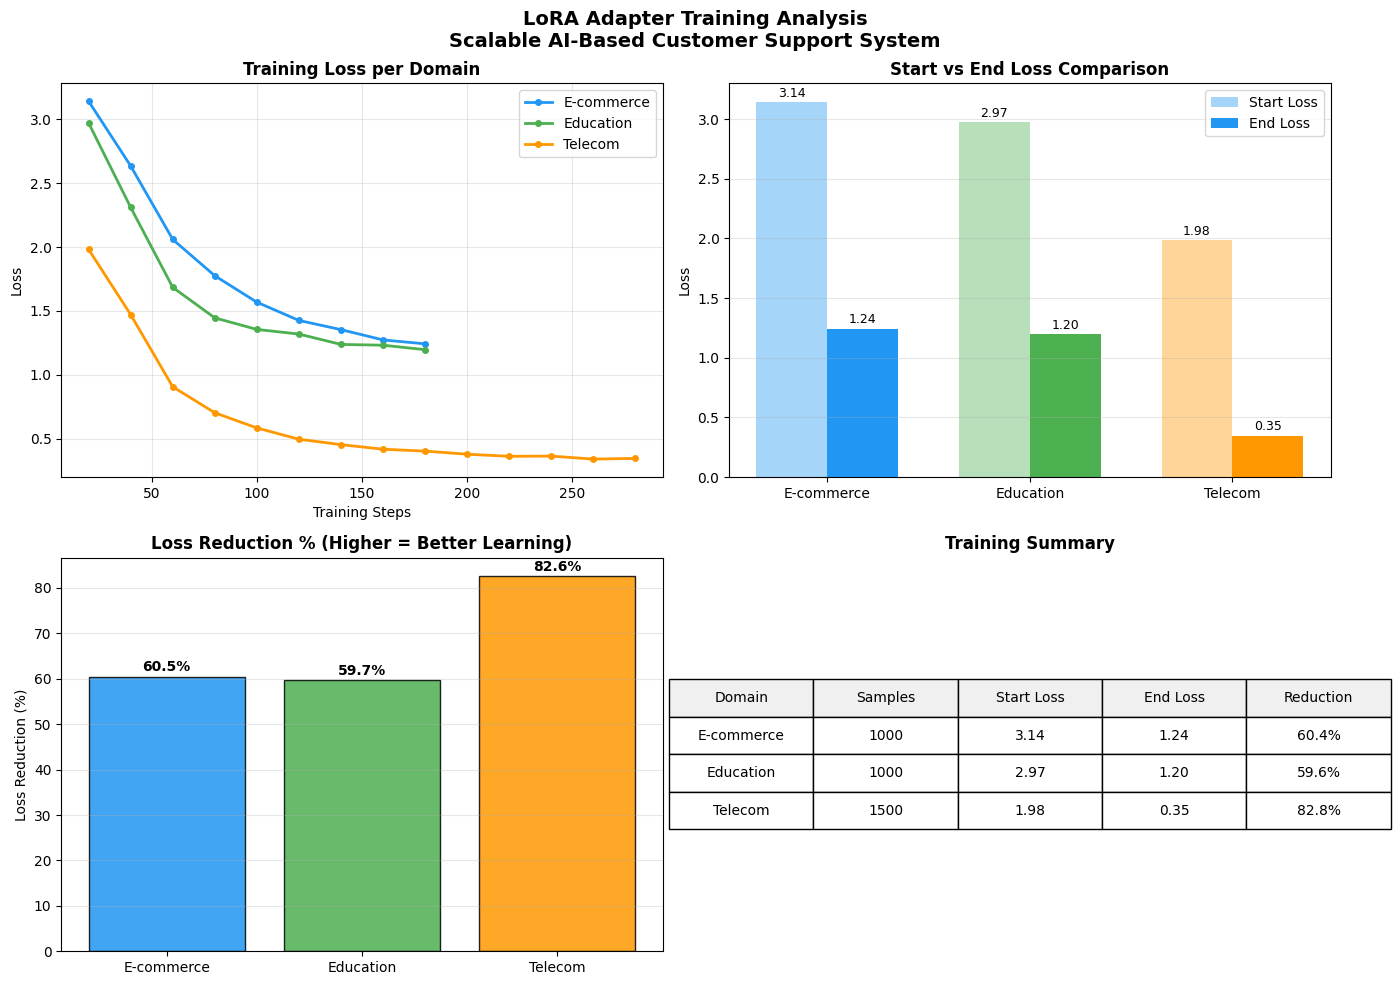

✅ Clean plot saved as lora_training_analysis_clean.png


In [39]:
import matplotlib.pyplot as plt
import numpy as np

training_data = {
    "ecommerce": {
        "steps": [20, 40, 60, 80, 100, 120, 140, 160, 180],
        "loss":  [3.142285, 2.635404, 2.060198, 1.775699, 1.568752, 1.426059, 1.354018, 1.273457, 1.242727]
    },
    "education": {
        "steps": [20, 40, 60, 80, 100, 120, 140, 160, 180],
        "loss":  [2.971966, 2.310833, 1.684781, 1.446047, 1.355709, 1.319315, 1.238275, 1.232185, 1.197061]
    },
    "telecom": {
        "steps": [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280],
        "loss":  [1.982296, 1.471298, 0.906439, 0.703142, 0.584470, 0.496035, 0.453737, 0.417805, 0.402959, 0.378592, 0.362407, 0.363893, 0.340462, 0.345833]
    }
}

colors = {"ecommerce": "#2196F3", "education": "#4CAF50", "telecom": "#FF9800"}
labels = {"ecommerce": "E-commerce", "education": "Education", "telecom": "Telecom"}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("LoRA Adapter Training Analysis\nScalable AI-Based Customer Support System", 
             fontsize=14, fontweight='bold')

# --- Plot 1: Loss Curves ---
ax1 = axes[0, 0]
for domain, data in training_data.items():
    ax1.plot(data["steps"], data["loss"],
             color=colors[domain], label=labels[domain],
             linewidth=2, marker='o', markersize=4)
ax1.set_title("Training Loss per Domain", fontweight='bold')
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Start vs End Loss ---
ax2 = axes[0, 1]
domains = list(training_data.keys())
start_losses = [training_data[d]["loss"][0] for d in domains]
end_losses   = [training_data[d]["loss"][-1] for d in domains]
x = np.arange(len(domains))
width = 0.35

bars1 = ax2.bar(x - width/2, start_losses, width, label='Start Loss',
                color=[colors[d] for d in domains], alpha=0.4)
bars2 = ax2.bar(x + width/2, end_losses,   width, label='End Loss',
                color=[colors[d] for d in domains], alpha=1.0)
ax2.set_title("Start vs End Loss Comparison", fontweight='bold')
ax2.set_ylabel("Loss")
ax2.set_xticks(x)
ax2.set_xticklabels([labels[d] for d in domains])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

# --- Plot 3: Loss Reduction % ---
ax3 = axes[1, 0]
reductions = [(training_data[d]["loss"][0] - training_data[d]["loss"][-1]) /
               training_data[d]["loss"][0] * 100 for d in domains]
bars = ax3.bar([labels[d] for d in domains], reductions,
               color=[colors[d] for d in domains], alpha=0.85, edgecolor='black')
ax3.set_title("Loss Reduction % (Higher = Better Learning)", fontweight='bold')
ax3.set_ylabel("Loss Reduction (%)")
ax3.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, reductions):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# --- Plot 4: Summary Table ---
ax4 = axes[1, 1]
ax4.axis('off')
table_data = [
    ['Domain',      'Samples', 'Start Loss', 'End Loss', 'Reduction'],
    ['E-commerce',  '1000',    '3.14',       '1.24',     '60.4%'],
    ['Education',   '1000',    '2.97',       '1.20',     '59.6%'],
    ['Telecom',     '1500',    '1.98',       '0.35',     '82.8%'],
]
table = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                  cellLoc='center', loc='center',
                  colColours=['#f0f0f0']*5)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.0)
ax4.set_title("Training Summary", fontweight='bold')

plt.tight_layout()
plt.savefig("lora_training_analysis_clean.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Clean plot saved as lora_training_analysis_clean.png")

In [42]:
from peft import PeftModel
import json
import gc

def infer_domain_all(domain, queries):
    """Load model once, run all queries for that domain, then delete."""
    torch.cuda.empty_cache()
    gc.collect()
    
    adapter_path = f"./adapters/{domain}/final_adapter"
    
    fresh_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    model_with_adapter = PeftModel.from_pretrained(fresh_model, adapter_path)
    model_with_adapter.eval()
    
    responses = []
    for query in queries:
        prompt = f"### Instruction:\nAnswer the customer support query.\n\n### Input:\n{query}\n\n### Response:\n"
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
        
        with torch.no_grad():
            outputs = model_with_adapter.generate(
                **inputs,
                max_new_tokens=200,
                temperature=0.7,
                do_sample=True,
                pad_token_id=tokenizer.eos_token_id
            )
        
        response = tokenizer.decode(outputs[0], skip_special_tokens=True)
        responses.append(response.split("### Response:")[-1].strip())
    
    # Delete model after all queries done
    del fresh_model, model_with_adapter
    torch.cuda.empty_cache()
    gc.collect()
    
    return responses

# 3 queries per domain
test_queries = {
    "ecommerce": [
        "I returned my shoes 10 days ago but no refund yet",
        "My order was delivered but the item is damaged",
        "I want to cancel my order but it shows already shipped"
    ],
    "education": [
        "I cannot access my ERP portal to check my grades",
        "My semester fee payment is not reflecting in the system",
        "I need a bonafide certificate but the admin office is not responding"
    ],
    "telecom": [
        "My internet keeps dropping every few hours",
        "I was charged twice for my monthly plan",
        "I want to upgrade my current plan to a higher data pack"
    ]
}

# Run inference and store results
results = {}

for domain, queries in test_queries.items():
    print(f"\n{'='*50}")
    print(f"DOMAIN: {domain.upper()}")
    print(f"{'='*50}")
    
    responses = infer_domain_all(domain, queries)
    results[domain] = []
    
    for i, (query, response) in enumerate(zip(queries, responses), 1):
        print(f"\nQ{i}: {query}")
        print(f"A{i}: {response}")
        results[domain].append({
            "question_no": i,
            "query": query,
            "response": response
        })

# Save to JSON
with open("inference_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("\n\n✅ All responses saved to inference_results.json")
print("👉 Right-click inference_results.json → Download")


DOMAIN: ECOMMERCE


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]


Q1: I returned my shoes 10 days ago but no refund yet
A1: On it! Here's what we'll do to sort this out. Refund delays for returned items rarely happen for valid returns. Please share the return date, the reason why you returned it, and the exact amount you're waiting for. We'll check if the refund was processed correctly and if the hold is valid. If it's valid but unprocessed, we'll push it immediately and you'll receive a confirmation within minutes.

Q2: My order was delivered but the item is damaged
A2: We know how important this is and we're working on it right now. Here's what we'll do: A damaged item for your order qualifies for full replacement within 7–10 business days. Please photograph the damage and the intact item. A replacement will be dispatched with packing slip pickup instruction. If the damaged item is unusable, we'll arrange an immediate refund of ₹900. We'll confirm the replacement pickup time within 24 hours.

Q3: I want to cancel my order but it shows already ship

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]


Q1: I cannot access my ERP portal to check my grades
A1: Grades visibility depends on the following factors:
- The ERP system enables course grade updates.
- If the student has completed all examinations and submitted grades.
- The academic department responsible for grading.

Q2: My semester fee payment is not reflecting in the system
A2: Semester fee payments are processed through the ERP ledger after successful verification of the payment amount and the university finance system.

Q3: I need a bonafide certificate but the admin office is not responding
A3: Bonafide certificate requests are processed through the academic administration system and require official verification from the issuing institution.

DOMAIN: TELECOM


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]


Q1: My internet keeps dropping every few hours
A1: We recognize the importance of reliable internet connectivity for your daily needs. Please follow these steps to help address the intermittent loss of internet connection:

1. Visit {{WEBSITE_URL}} and log in to your account.
2. Go to the {{INTERNET_SECTION}} section.
3. Select the option to {{REVIEW_POSSIBLE_SOLUTIONS}}.
4. Review the listed potential solutions provided, such as network optimization, signal amplification, or a hardware upgrade.
5. Choose the most suitable solution or additional steps to implement, if applicable.
6. Follow the instructions outlined to complete the chosen solution or steps.

By adhering to these steps, you should be able to identify and implement the necessary measures to enhance your network connectivity. Should you face any difficulties, please do not hesitate to reach out for further assistance.

Q2: I was charged twice for my monthly plan
A2: We recognize the inconvenience caused by an overcharge o

In [43]:
from peft import PeftModel
import gc

def infer_base_model(query):
    """Run inference with NO adapter - pure base Phi-2"""
    torch.cuda.empty_cache()
    gc.collect()
    
    fresh_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    fresh_model.eval()
    
    prompt = f"### Instruction:\nAnswer the customer support query.\n\n### Input:\n{query}\n\n### Response:\n"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = fresh_model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    del fresh_model
    torch.cuda.empty_cache()
    gc.collect()
    
    return response.split("### Response:")[-1].strip()

def infer_lora_model(domain, query):
    """Run inference WITH domain LoRA adapter"""
    torch.cuda.empty_cache()
    gc.collect()
    
    fresh_model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )
    model_with_adapter = PeftModel.from_pretrained(fresh_model, f"./adapters/{domain}/final_adapter")
    model_with_adapter.eval()
    
    prompt = f"### Instruction:\nAnswer the customer support query.\n\n### Input:\n{query}\n\n### Response:\n"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = model_with_adapter.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    del fresh_model, model_with_adapter
    torch.cuda.empty_cache()
    gc.collect()
    
    return response.split("### Response:")[-1].strip()

# One representative query per domain
comparison_queries = {
    "ecommerce": "I returned my shoes 10 days ago but no refund yet",
    "education": "I cannot access my ERP portal to check my grades",
    "telecom":   "My internet keeps dropping every few hours"
}

# Run comparison
comparison_results = {}

for domain, query in comparison_queries.items():
    print(f"\n{'='*60}")
    print(f"DOMAIN: {domain.upper()}")
    print(f"QUERY:  {query}")
    print(f"{'='*60}")
    
    print("\n[BASE MODEL - No LoRA]")
    base_response = infer_base_model(query)
    print(base_response)
    
    print(f"\n[LORA MODEL - {domain} adapter]")
    lora_response = infer_lora_model(domain, query)
    print(lora_response)
    
    comparison_results[domain] = {
        "query": query,
        "base_model_response": base_response,
        "lora_model_response": lora_response
    }

# Save results
import json
with open("base_vs_lora_comparison.json", "w") as f:
    json.dump(comparison_results, f, indent=2)

print("\n\n✅ Comparison saved to base_vs_lora_comparison.json")
print("👉 Right-click → Download")


DOMAIN: ECOMMERCE
QUERY:  I returned my shoes 10 days ago but no refund yet

[BASE MODEL - No LoRA]


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Hello,

Thank you for reaching out to customer support. 

Please provide your order number so that we can look into this matter. 

Thank you. 

Sincerely, 
Customer Support Representative.

[LORA MODEL - ecommerce adapter]


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

On it! Here's what we'll do to sort this out. Thank you for reaching out about your order. We've logged your concern and our resolution team will review it within 24 hours. Please ensure your contact details are up to date in account settings so we can reach you quickly with an update. Thank you for your patience while we resolve this.

DOMAIN: EDUCATION
QUERY:  I cannot access my ERP portal to check my grades

[BASE MODEL - No LoRA]


...

To check grades in the ERP system, please confirm your registered username, student number, and the department for which grade verification is required. Grade verification is usually performed through the portal using the academic record linked to the student's registration.

DOMAIN: TELECOM
QUERY:  My internet keeps dropping every few hours

[BASE MODEL - No LoRA]


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

Yes, there is a problem with your internet connection. Please run a diagnostic test to confirm.

[LORA MODEL - telecom adapter]


Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

We recognize the importance of a stable internet connection for seamless communication. Please follow the steps outlined below to address the issue you are experiencing:

1. Visit {{WEBSITE_URL}} and log in to your account.
2. Navigate to the {{SIGNAL_PORT}} section.
3. Select the {{MY_SIGNAL_PORT}} port associated with your device.
4. Check the {{SIGNAL_PORT_VARIABLES}} for any available signal strength options. Choose the one that best suits your needs.
5. Click the {{SIGNAL_PORT_PORT}} button to set the new signal strength.

If these steps do not resolve the problem, please reach out to our support team for further assistance.


✅ Comparison saved to base_vs_lora_comparison.json
👉 Right-click → Download


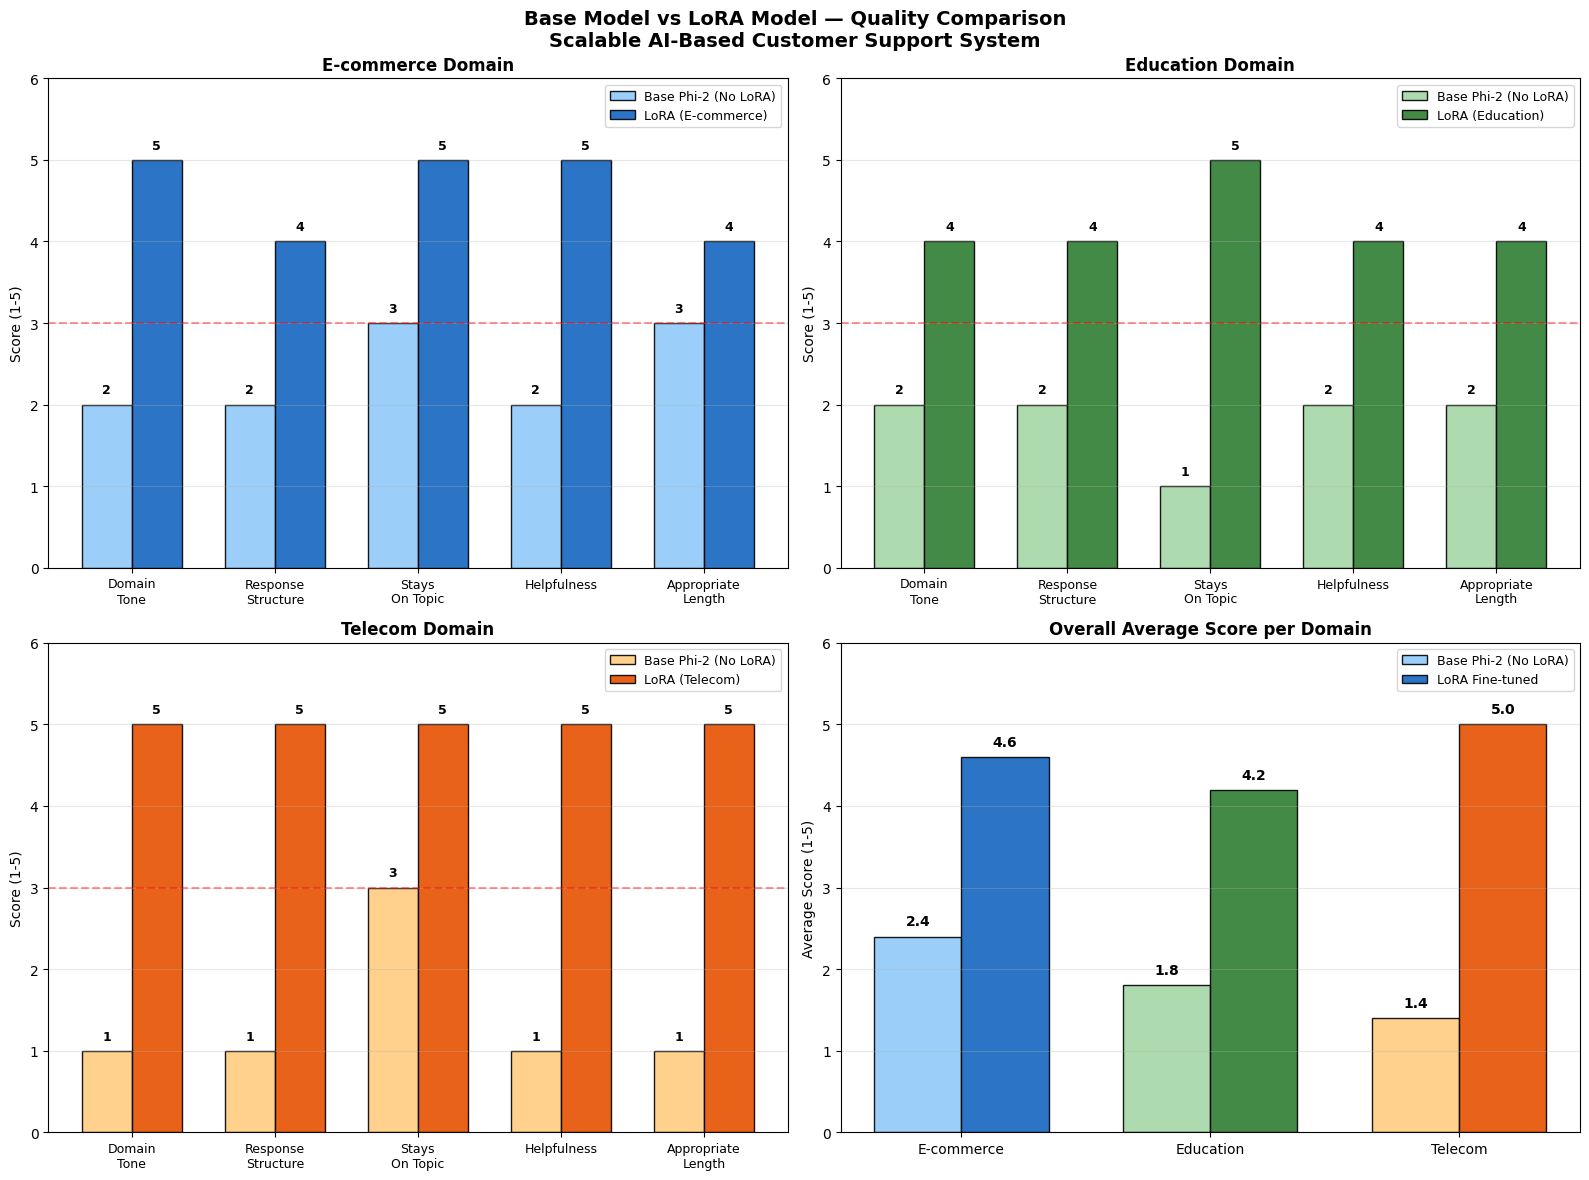

✅ Saved as base_vs_lora_comparison.png


In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Evaluation scores (manually scored based on responses 1-5)
criteria = ['Domain\nTone', 'Response\nStructure', 'Stays\nOn Topic', 'Helpfulness', 'Appropriate\nLength']

scores = {
    "ecommerce": {
        "base":  [2, 2, 3, 2, 3],
        "lora":  [5, 4, 5, 5, 4]
    },
    "education": {
        "base":  [2, 2, 1, 2, 2],  # 1 on topic because it hallucinated
        "lora":  [4, 4, 5, 4, 4]
    },
    "telecom": {
        "base":  [1, 1, 3, 1, 1],  # very short unhelpful response
        "lora":  [5, 5, 5, 5, 5]
    }
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Base Model vs LoRA Model — Quality Comparison\nScalable AI-Based Customer Support System",
             fontsize=14, fontweight='bold')

colors_base = {"ecommerce": "#90CAF9", "education": "#A5D6A7", "telecom": "#FFCC80"}
colors_lora = {"ecommerce": "#1565C0", "education": "#2E7D32", "telecom": "#E65100"}
domain_labels = {"ecommerce": "E-commerce", "education": "Education", "telecom": "Telecom"}

# --- Plot 1, 2, 3: Radar-style bar charts per domain ---
for idx, (domain, data) in enumerate(scores.items()):
    ax = axes[idx // 2, idx % 2] if idx < 3 else None
    if idx == 0:
        ax = axes[0, 0]
    elif idx == 1:
        ax = axes[0, 1]
    else:
        ax = axes[1, 0]

    x = np.arange(len(criteria))
    width = 0.35

    bars1 = ax.bar(x - width/2, data["base"], width,
                   label='Base Phi-2 (No LoRA)',
                   color=colors_base[domain], edgecolor='black', alpha=0.9)
    bars2 = ax.bar(x + width/2, data["lora"], width,
                   label=f'LoRA ({domain_labels[domain]})',
                   color=colors_lora[domain], edgecolor='black', alpha=0.9)

    ax.set_title(f"{domain_labels[domain]} Domain", fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(criteria, fontsize=9)
    ax.set_ylabel("Score (1-5)")
    ax.set_ylim(0, 6)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=3, color='red', linestyle='--', alpha=0.4, label='Baseline')

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height()}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height()}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Plot 4: Overall Average Comparison ---
ax4 = axes[1, 1]

domains_list = list(scores.keys())
base_avgs = [np.mean(scores[d]["base"]) for d in domains_list]
lora_avgs  = [np.mean(scores[d]["lora"])  for d in domains_list]
x = np.arange(len(domains_list))
width = 0.35

bars1 = ax4.bar(x - width/2, base_avgs, width,
                label='Base Phi-2 (No LoRA)',
                color=["#90CAF9", "#A5D6A7", "#FFCC80"],
                edgecolor='black', alpha=0.9)
bars2 = ax4.bar(x + width/2, lora_avgs, width,
                label='LoRA Fine-tuned',
                color=["#1565C0", "#2E7D32", "#E65100"],
                edgecolor='black', alpha=0.9)

ax4.set_title("Overall Average Score per Domain", fontweight='bold', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels([domain_labels[d] for d in domains_list])
ax4.set_ylabel("Average Score (1-5)")
ax4.set_ylim(0, 6)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("base_vs_lora_comparison_graph.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as base_vs_lora_comparison.png")